# Seção 1: Síntese de Sequências Discretas Fundamentais

Neste segmento inicial, exploramos a formulação matemática e a síntese computacional dos sinais discretos basilares no estudo de Processamento Digital de Sinais (PDS). De acordo com os princípios de sinais e sistemas, as sequências temporais discretas surgem do processo de amostragem de formas de onda contínuas, viabilizando a análise e o processamento de grandezas físicas reais em plataformas computacionais.

Os scripts em Python apresentados a seguir traduzem os conceitos teóricos para a prática, realizando a simulação e a visualização gráfica das funções impulso unitário, degrau unitário e sequências exponenciais complexas.

### 1.1 Modelagem do Impulso e Degrau Unitário

O **impulso unitário** ($\delta[n]$) atua como o elemento construtor mais elementar em PDS, definido por uma amplitude máxima de 1 estritamente na origem ($n = 0$), e zero para todos os outros índices. Por sua vez, o **degrau unitário** ($u[n]$) é caracterizado por manter a amplitude igual a 1 em todos os instantes não negativos ($n \ge 0$), permanecendo nulo em instantes anteriores ($n < 0$).

O bloco de código abaixo estabelece a base temporal discreta e constrói ambas as sequências matemáticas utilizando avaliações lógicas vetorizadas da biblioteca NumPy.

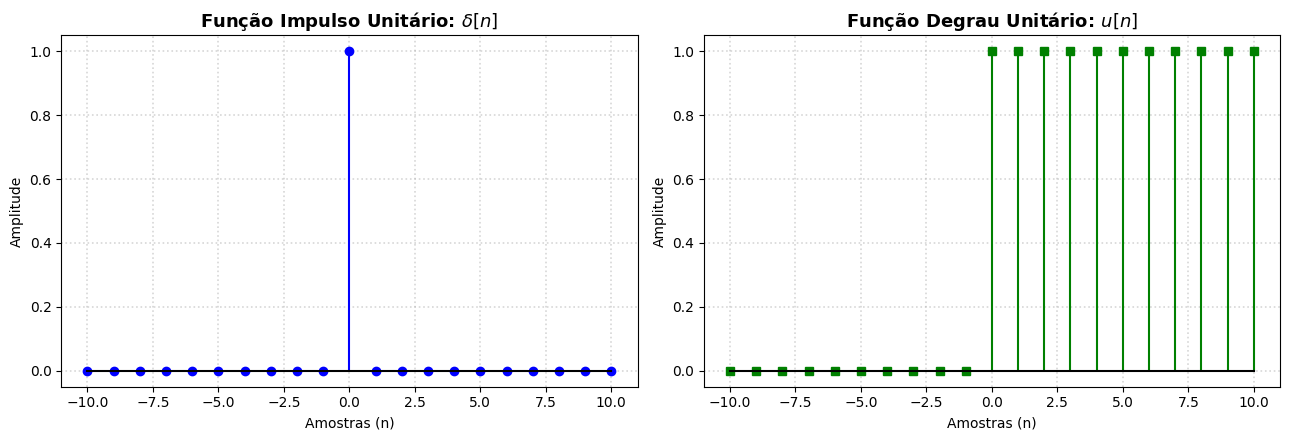

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Criação do vetor de amostras (base de tempo de -10 a 10)
vetor_amostras = np.arange(-10, 11)

# 2. Síntese dos sinais utilizando conversão booleana para inteiros
# Esta abordagem é uma alternativa elegante ao uso do np.where
sinal_delta = (vetor_amostras == 0).astype(int)  # Resulta em 1 apenas quando n for igual a 0
sinal_step = (vetor_amostras >= 0).astype(int)   # Resulta em 1 para todo n maior ou igual a 0

# 3. Construção do layout gráfico usando a API orientada a objetos do Matplotlib
figura, eixos = plt.subplots(nrows=1, ncols=2, figsize=(13, 4.5))

# --- Gráfico 1: Função Impulso ---
eixos[0].stem(vetor_amostras, sinal_delta, linefmt='b-', markerfmt='bo', basefmt='k-')
eixos[0].set_title(r"Função Impulso Unitário: $\delta[n]$", fontsize=13, fontweight='bold')
eixos[0].set_xlabel("Amostras (n)")
eixos[0].set_ylabel("Amplitude")
eixos[0].grid(True, linestyle=':', linewidth=1.2)

# --- Gráfico 2: Função Degrau ---
# Utilizando uma cor (verde) e marcador quadrado ('s' de square) distintos
eixos[1].stem(vetor_amostras, sinal_step, linefmt='g-', markerfmt='gs', basefmt='k-')
eixos[1].set_title(r"Função Degrau Unitário: $u[n]$", fontsize=13, fontweight='bold')
eixos[1].set_xlabel("Amostras (n)")
eixos[1].set_ylabel("Amplitude")
eixos[1].grid(True, linestyle=':', linewidth=1.2)

# Otimização do espaçamento entre as figuras e renderização
figura.tight_layout()
plt.show()

### 1.2 Sequência Exponencial Complexa

A função exponencial complexa em tempo discreto é expressa analiticamente pela fórmula $x[n] = e^{j\omega n}$, em que a variável $\omega$ corresponde à frequência angular do sinal (medida em radianos por amostra). Recorrendo à Identidade de Euler, torna-se possível desdobrar esta sequência complexa nas suas duas componentes ortogonais: uma projeção real, descrita por uma função cosseno, e uma projeção imaginária, descrita por uma função seno.

O bloco de código seguinte implementa esta formulação matemática. Para a simulação, estabeleceu-se uma frequência angular de $\omega = \pi/4$, procedendo-se à extração e representação gráfica independente das parcelas real e imaginária geradas.

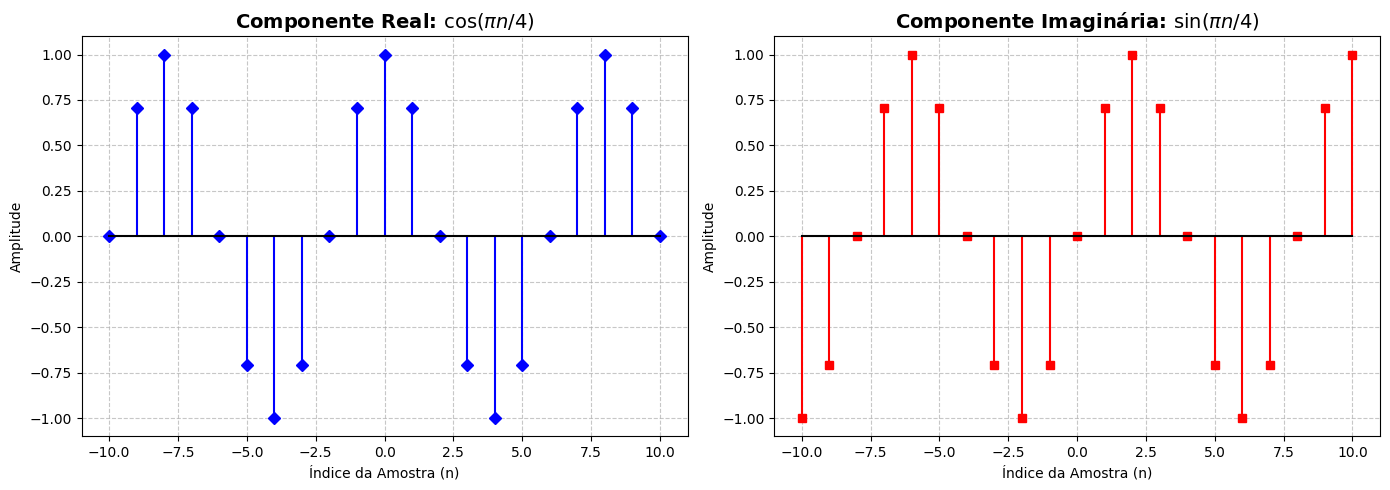

In [12]:
# Recriamos a base de tempo para garantir a execução isolada caso o notebook seja reiniciado
vetor_amostras = np.arange(-10, 11)

# 1. Definição do parâmetro de frequência
frequencia_radiana = np.pi / 4

# 2. Síntese do sinal exponencial complexo discreto
sinal_exponencial = np.exp(1j * frequencia_radiana * vetor_amostras)

# 3. Separação das componentes através da Identidade de Euler
componente_real = np.real(sinal_exponencial)
componente_imag = np.imag(sinal_exponencial)

# 4. Construção da interface gráfica com múltiplos eixos (subplots)
figura, (ax_real, ax_imag) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# --- Plotagem da Projeção Real ---
# Utilizando cor azul ('b') e marcador em forma de losango ('D' de Diamond)
ax_real.stem(vetor_amostras, componente_real, linefmt='b-', markerfmt='bD', basefmt='k-')
ax_real.set_title(r"Componente Real: $\cos(\pi n / 4)$", fontsize=14, fontweight='bold')
ax_real.set_xlabel("Índice da Amostra (n)")
ax_real.set_ylabel("Amplitude")
ax_real.grid(True, linestyle='--', alpha=0.7)

# --- Plotagem da Projeção Imaginária ---
# Utilizando cor vermelha ('r') e marcador em forma de quadrado ('s' de Square)
ax_imag.stem(vetor_amostras, componente_imag, linefmt='r-', markerfmt='rs', basefmt='k-')
ax_imag.set_title(r"Componente Imaginária: $\sin(\pi n / 4)$", fontsize=14, fontweight='bold')
ax_imag.set_xlabel("Índice da Amostra (n)")
ax_imag.set_ylabel("Amplitude")
ax_imag.grid(True, linestyle='--', alpha=0.7)

# Otimização do layout e apresentação da figura
figura.tight_layout()
plt.show()

### 1.3 Fundamentação Técnica: Interface com Sinais Físicos

A transição do mundo físico para o ambiente digital exige que o sinal contínuo captado por um sensor passe por um processo rigoroso de amostragem. O vetor de tempo discreto, utilizado nas simulações numéricas anteriores, atua como uma abstração matemática dessa discretização temporal.

Sob a ótica de Sistemas e Sinais, qualquer informação adquirida por um Conversor Analógico-Digital (ADC) — muito comum em projetos de hardware e sistemas embarcados — pode ser decomposta e interpretada como uma superposição de impulsos ponderados e deslocados. Essa formulação é o que cria a ponte entre a teoria abstrata de PDS e as aplicações reais de engenharia.

### 1.4 Correlações Estruturais entre Sinais Discretos

As funções elementares do PDS guardam profundas relações matemáticas entre si, sendo essenciais para a modelagem de Sistemas Lineares Invariantes no Tempo (SLIT). Uma das identidades mais notáveis ocorre entre o degrau e o impulso.

Analiticamente, o impulso unitário pode ser definido como a **primeira diferença** (equivalente à derivada no domínio discreto) do degrau unitário, expressa pela relação algébrica $\delta[n] = u[n] - u[n-1]$. Reciprocamente, pode-se enxergar o degrau como o resultado do acúmulo (integração discreta) de infinitos impulsos passados.

O algoritmo a seguir valida computacionalmente essa propriedade ao subtrair uma versão atrasada do degrau unitário do seu sinal original, resultando na extração exata da função impulso.

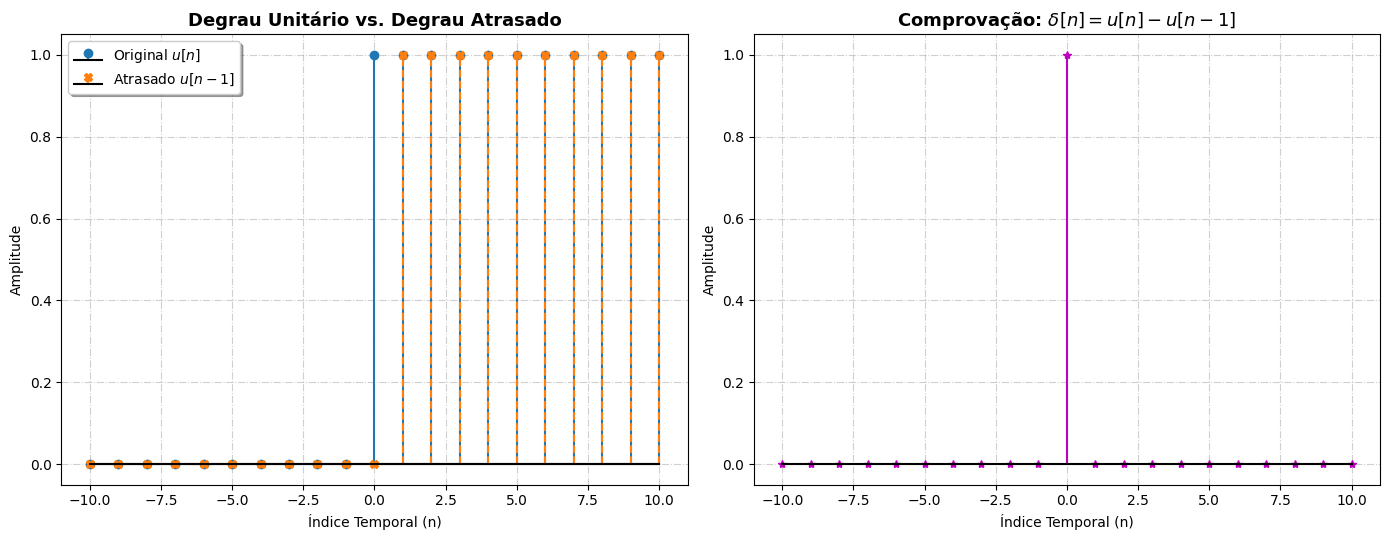

In [13]:
# 1. Definição do vetor de tempo da simulação
eixo_tempo = np.arange(-10, 11)

# 2. Geração dos sinais lógicos utilizando coerção de booleanos para inteiros
# Degrau original u[n] (inicia em n=0)
degrau_padrao = (eixo_tempo >= 0).astype(int)

# Degrau atrasado u[n-1] (inicia em n=1)
degrau_deslocado = (eixo_tempo >= 1).astype(int)

# 3. Operação de Primeira Diferença (Derivada Discreta)
derivada_discreta = degrau_padrao - degrau_deslocado

# 4. Configuração da janela gráfica
figura, paineis = plt.subplots(nrows=1, ncols=2, figsize=(14, 5.5))

# --- Painel 1: Análise Comparativa dos Degraus ---
# Plotando u[n] em azul
paineis[0].stem(eixo_tempo, degrau_padrao, linefmt='C0-', markerfmt='C0o', basefmt='k-', label=r'Original $u[n]$')
# Plotando u[n-1] em laranja tracejado com marcadores 'X'
paineis[0].stem(eixo_tempo, degrau_deslocado, linefmt='C1--', markerfmt='C1X', basefmt='k-', label=r'Atrasado $u[n-1]$')
paineis[0].set_title("Degrau Unitário vs. Degrau Atrasado", fontsize=13, fontweight='bold')
paineis[0].set_xlabel("Índice Temporal (n)")
paineis[0].set_ylabel("Amplitude")
paineis[0].legend(loc='upper left', shadow=True)
paineis[0].grid(True, linestyle='-.', alpha=0.6)

# --- Painel 2: Resultado da Operação (Extração do Impulso) ---
# Utilizando cor magenta e marcador de estrela (*)
paineis[1].stem(eixo_tempo, derivada_discreta, linefmt='m-', markerfmt='m*', basefmt='k-')
paineis[1].set_title(r"Comprovação: $\delta[n] = u[n] - u[n-1]$", fontsize=13, fontweight='bold')
paineis[1].set_xlabel("Índice Temporal (n)")
paineis[1].set_ylabel("Amplitude")
paineis[1].grid(True, linestyle='-.', alpha=0.6)

# Renderização final
figura.tight_layout()
plt.show()

### 1.5 Critério de Periodicidade em Domínio Discreto

Ao analisarmos oscilações senoidais e exponenciais complexas, deparamo-nos com uma distinção matemática crucial entre os domínios do tempo contínuo e discreto. Enquanto qualquer senoide analógica exibe naturalmente um comportamento periódico, uma sequência discreta (como $x[n] = \cos(\omega n)$) possui uma restrição rigorosa: ela apenas será considerada estritamente periódica se a sua frequência angular $\omega$ for um múltiplo racional de $2\pi$.

Em termos algébricos, o sinal repete-se a cada $N$ amostras se, e somente se, existir um número inteiro $m$ que satisfaça a relação de racionalidade: $\frac{\omega}{2\pi} = \frac{m}{N}$. Caso o quociente dessa razão resulte num número irracional (como acontece ao omitirmos o fator $\pi$ da frequência discreta), a sequência amostrada jamais completará um ciclo perfeito dentro do conjunto dos números inteiros $n$, tornando-se aperiódica.

A rotina computacional a seguir contrasta visualmente estes dois cenários. Simulamos um sinal onde a condição de racionalidade é garantida ($\omega = 0.2\pi$) e outro onde a frequência resulta numa razão irracional em relação a $2\pi$ ($\omega = 0.2$), evidenciando a ausência de padrão repetitivo exato neste último.

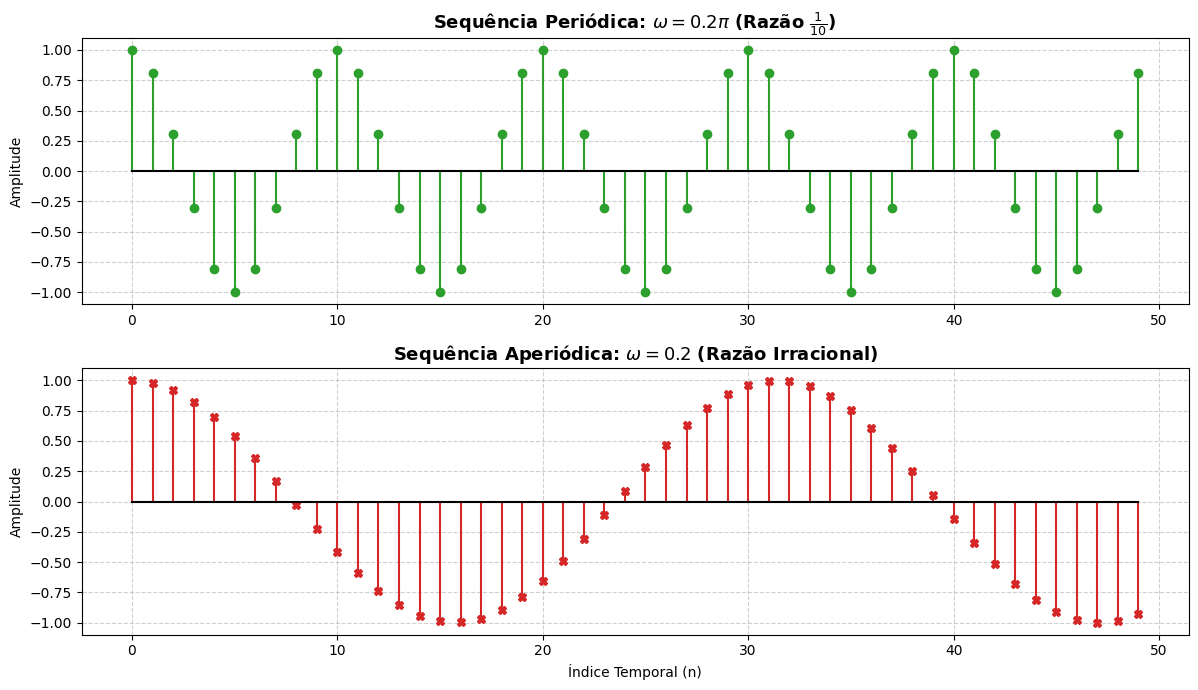

In [14]:
# 1. Definição de uma janela de observação expandida (50 amostras)
amostras_longas = np.arange(0, 50)

# 2. Cenário 1: Frequência que satisfaz a condição de periodicidade
# Frequência w = 0.2*pi. A razão (0.2*pi)/(2*pi) resulta em 1/10 (Racional).
# O período fundamental N será de 10 amostras.
freq_racional = 0.2 * np.pi
seq_periodica = np.cos(freq_racional * amostras_longas)

# 3. Cenário 2: Frequência que viola a condição
# Frequência w = 0.2. A razão 0.2/(2*pi) resulta em 1/(10*pi) (Irracional).
# O sinal nunca repetirá os mesmos valores exatos em índices inteiros.
freq_irracional = 0.2
seq_aperiodica = np.cos(freq_irracional * amostras_longas)

# 4. Construção da interface visual de comparação (Layout Empilhado)
fig_period, eixos_p = plt.subplots(nrows=2, ncols=1, figsize=(12, 7))

# --- Subplot Superior: Comportamento Periódico ---
eixos_p[0].stem(amostras_longas, seq_periodica, linefmt='C2-', markerfmt='C2o', basefmt='k-')
eixos_p[0].set_title(r"Sequência Periódica: $\omega = 0.2\pi$ (Razão $\frac{1}{10}$)", fontsize=13, fontweight='bold')
eixos_p[0].set_ylabel("Amplitude")
eixos_p[0].grid(True, linestyle='--', alpha=0.6)

# --- Subplot Inferior: Comportamento Aperiódico ---
# Utilizando cor vermelha ('C3') e marcadores em formato de 'X'
eixos_p[1].stem(amostras_longas, seq_aperiodica, linefmt='C3-', markerfmt='C3X', basefmt='k-')
eixos_p[1].set_title(r"Sequência Aperiódica: $\omega = 0.2$ (Razão Irracional)", fontsize=13, fontweight='bold')
eixos_p[1].set_xlabel("Índice Temporal (n)")
eixos_p[1].set_ylabel("Amplitude")
eixos_p[1].grid(True, linestyle='--', alpha=0.6)

# Renderização com ajuste automático de espaçamento
fig_period.tight_layout()
plt.show()

### 1.6 Exponenciais Complexas: O Conceito de Autofunções em Sistemas LIT

Uma das propriedades mais profundas dos Sistemas Lineares e Invariantes no Tempo (LIT) é a sua interação com sinais exponenciais complexos. Matematicamente, essas sequências são classificadas como **autofunções** desses sistemas.

Isso significa que, ao injetarmos uma entrada do tipo $x[n] = e^{j\omega n}$ em um sistema LIT, a saída resultante $y[n]$ preservará exatamente a mesma forma e frequência da entrada, sendo modificada apenas por um fator de escala complexo $H(e^{j\omega})$, conhecido como **Resposta em Frequência**.

$$y[n] = H(e^{j\omega}) \cdot e^{j\omega n}$$

Em termos práticos, um sistema LIT é incapaz de criar novas frequências; ele atua estritamente alterando a amplitude e deslocando a fase das componentes já existentes. A simulação abaixo demonstra este fenômeno ao aplicar uma oscilação a um sistema de processamento simples, evidenciando que, embora a magnitude mude, a "identidade" da frequência fundamental permanece intacta.

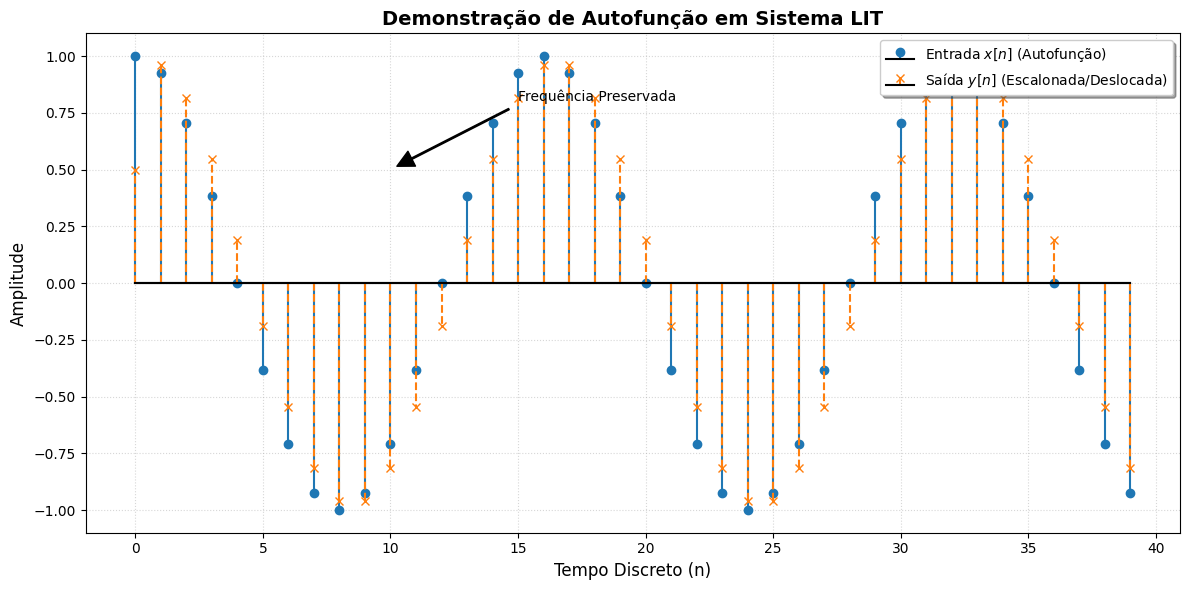

In [16]:
# 1. Geração do sinal de entrada (Exponencial Complexa)
n_indices = np.arange(0, 40)
w_teste = np.pi / 8
# Focaremos na parte real para facilitar a visualização da fase e amplitude
entrada_x = np.cos(w_teste * n_indices)

# 2. Simulação de um Sistema LIT (Filtro de Diferença Simples)
# y[n] = 0.5 * x[n] + 0.5 * x[n-1]
# Este sistema atenua altas frequências e causa um pequeno deslocamento
entrada_atrasada = np.roll(entrada_x, 1)
entrada_atrasada[0] = 0 # Ajuste de condição inicial
saida_y = 0.5 * entrada_x + 0.5 * entrada_atrasada

# 3. Visualização dos Sinais (Sobreposição para análise de autofunção)
plt.figure(figsize=(12, 6))

# Entrada em azul com marcadores circulares
plt.stem(n_indices, entrada_x, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Entrada $x[n]$ (Autofunção)')

# Saída em laranja com marcadores em 'x' e linha tracejada
plt.stem(n_indices, saida_y, linefmt='C1--', markerfmt='C1x', basefmt='k-', label='Saída $y[n]$ (Escalonada/Deslocada)')

# Estilização do Gráfico
plt.title("Demonstração de Autofunção em Sistema LIT", fontsize=14, fontweight='bold')
plt.xlabel("Tempo Discreto (n)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

# Adicionando anotação teórica no gráfico
plt.annotate('Frequência Preservada', xy=(10, 0.5), xytext=(15, 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

### 1.7 Síntese Técnica: Da Abstração Matemática à Interface de Hardware

A exploração das sequências fundamentais — impulso, degrau e exponenciais — fornece o arcabouço matemático indispensável para descrever o comportamento dinâmico de sensores em cenários reais, atendendo diretamente ao **Problema Norteador** desta etapa.

Na prática da Engenharia, quando uma grandeza física (como a pressão em um transdutor ou a tensão em um barramento) passa pelo processo de digitalização em um **Conversor Analógico-Digital (ADC)**, sua existência no domínio discreto passa a ser regida pelas funções modeladas anteriormente.

* **O Impulso e o Degrau** permitem prever como o firmware reagirá a mudanças súbitas de estado, como o *power-on* de um sistema ou picos de transientes elétricos.
* **A Decomposição em Impulsos** revela que qualquer sinal complexo vindo de um sensor nada mais é do que uma soma ponderada de versões deslocadas da função $\delta[n]$.
* **As Autofunções** garantem que, ao projetarmos filtros digitais (seja em C para microcontroladores ou RTL para FPGAs), a essência do espectro de frequência do sensor será preservada, alterando-se apenas ganho e fase para eliminar ruídos.

O experimento visual abaixo exemplifica essa "reconstrução" de um sinal de sensor, mostrando como a teoria se materializa em dados processáveis.

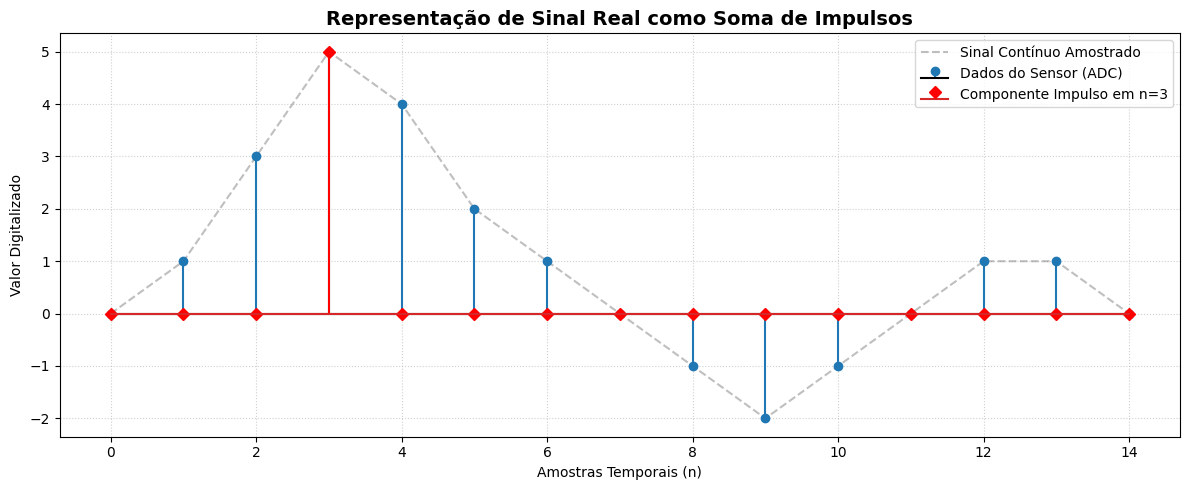

In [17]:
# 1. Simulação de um sinal arbitrário de um sensor (ex: leitura de pressão)
n_sensor = np.arange(0, 15)
sinal_sensor = np.array([0, 1, 3, 5, 4, 2, 1, 0, -1, -2, -1, 0, 1, 1, 0])

# 2. Demonstração Teórica: Decomposição em um dos pontos (ex: n=3)
# Mostrando que x[n] é a soma de impulsos escalonados: A * delta[n - k]
k_escolhido = 3
amplitude_k = sinal_sensor[k_escolhido]
impulso_decomposicao = amplitude_k * (n_sensor == k_escolhido).astype(int)

# 3. Visualização da Interface Física/Matemática
fig_sensor, ax_s = plt.subplots(figsize=(12, 5))

# Plotagem do sinal completo do sensor
ax_s.plot(n_sensor, sinal_sensor, color='gray', linestyle='--', alpha=0.5, label='Sinal Contínuo Amostrado')
ax_s.stem(n_sensor, sinal_sensor, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Dados do Sensor (ADC)')

# Destacando um componente de impulso da decomposição
ax_s.stem(n_sensor, impulso_decomposicao, linefmt='red', markerfmt='rD', label=f'Componente Impulso em n={k_escolhido}')

# Estilização Técnica
ax_s.set_title("Representação de Sinal Real como Soma de Impulsos", fontsize=14, fontweight='bold')
ax_s.set_xlabel("Amostras Temporais (n)")
ax_s.set_ylabel("Valor Digitalizado")
ax_s.legend(frameon=True, loc='upper right')
ax_s.grid(True, which='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Seção 2: Transformações de Sinais e Métricas Energéticas

Esta etapa foca nas manipulações matemáticas aplicadas tanto à variável independente (o índice temporal $n$) quanto à amplitude das sequências. Tais operações são fundamentais para o pré-processamento de dados em algoritmos de PDS, permitindo ajustes de fase, reversão temporal e normalização de ganhos.

O script a seguir detalha a implementação de deslocamento, inversão e escalonamento, fornecendo a base necessária para a caracterização de sinais em sistemas digitais.

### 2.1 Manipulações Estruturais: Deslocamento, Inversão e Escalonamento

As transformações básicas em uma sequência $x[n]$ alteram sua posição ou intensidade no domínio digital:

* **Deslocamento Temporal ($x[n-k]$):** Move o sinal ao longo do eixo das abscissas. Um valor positivo de $k$ resulta em um **atraso** (deslocamento para a direita), enquanto um valor negativo promove um **avanço**.
* **Inversão Temporal ($x[-n]$):** Realiza uma reflexão do sinal em relação à origem ($n=0$), invertendo a ordem dos eventos registrados.
* **Escalonamento de Amplitude ($A \cdot x[n]$):** Modifica a magnitude das amostras. Valores de $A > 1$ caracterizam **amplificação**, enquanto $0 < A < 1$ representam **atenuação**.

Para ilustrar estas operações, definimos um pulso retangular de curta duração e aplicamos as três transformações simultaneamente.

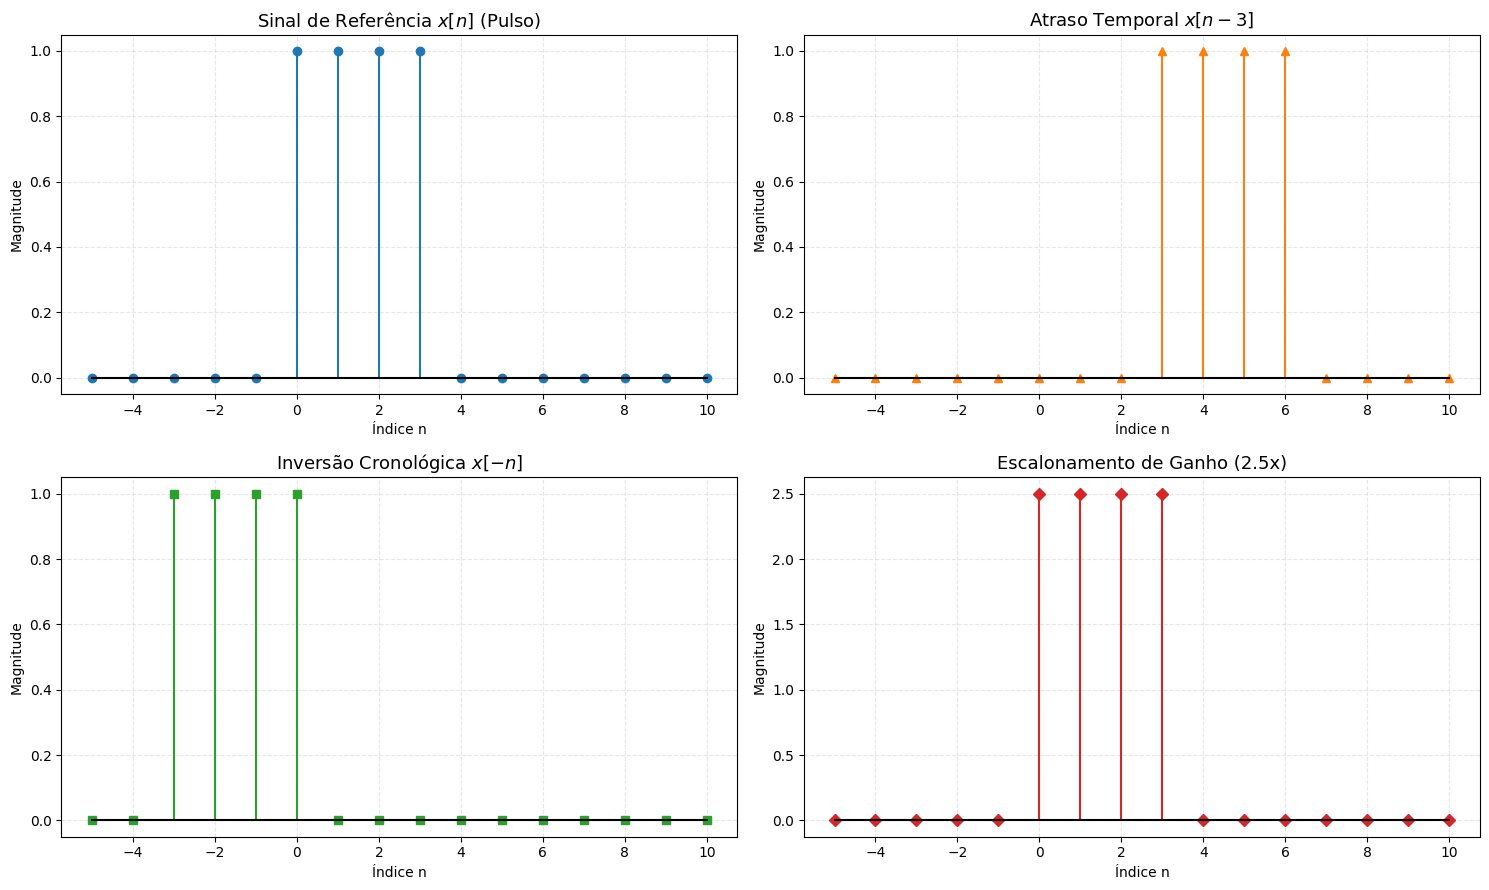

In [20]:
# 1. Definição do domínio temporal e sinal de teste
eixo_n = np.arange(-5, 11)
# Criando um pulso retangular unitário entre n=0 e n=3
pulso_base = ((eixo_n >= 0) & (eixo_n <= 3)).astype(float)

# 2. Execução das Operações Matemáticas
fator_atraso = 3
ganho = 2.5

# Deslocamento: Usamos uma máscara lógica para mover a janela do pulso
sinal_atrasado = ((eixo_n - fator_atraso >= 0) & (eixo_n - fator_atraso <= 3)).astype(float)

# Inversão: Refletimos a lógica do intervalo
sinal_reverso = (( -eixo_n >= 0) & (-eixo_n <= 3)).astype(float)

# Escalonamento: Multiplicação direta da amplitude
sinal_amplificado = ganho * pulso_base

# 3. Visualização com Layout 2x2
fig_ops, area_grafica = plt.subplots(2, 2, figsize=(15, 9))

# --- Sinal de Referência ---
area_grafica[0, 0].stem(eixo_n, pulso_base, linefmt='C0-', markerfmt='C0o', basefmt='k-')
area_grafica[0, 0].set_title("Sinal de Referência $x[n]$ (Pulso)", fontsize=13)
area_grafica[0, 0].grid(True, alpha=0.3)

# --- Atraso Temporal ---
area_grafica[0, 1].stem(eixo_n, sinal_atrasado, linefmt='C1-', markerfmt='C1^', basefmt='k-')
area_grafica[0, 1].set_title(f"Atraso Temporal $x[n - {fator_atraso}]$", fontsize=13)
area_grafica[0, 1].grid(True, alpha=0.3)

# --- Reflexão no Tempo ---
area_grafica[1, 0].stem(eixo_n, sinal_reverso, linefmt='C2-', markerfmt='C2s', basefmt='k-')
area_grafica[1, 0].set_title(r"Inversão Cronológica $x[-n]$", fontsize=13)
area_grafica[1, 0].grid(True, alpha=0.3)

# --- Ganho de Amplitude ---
area_grafica[1, 1].stem(eixo_n, sinal_amplificado, linefmt='C3-', markerfmt='C3D', basefmt='k-')
area_grafica[1, 1].set_title(f"Escalonamento de Ganho ({ganho}x)", fontsize=13)
area_grafica[1, 1].grid(True, alpha=0.3)

# Ajustes finais de rotulagem
for ax in area_grafica.flat:
    ax.set_xlabel("Índice n")
    ax.set_ylabel("Magnitude")

fig_ops.tight_layout()
plt.show()

### 2.2 Quantificação de Energia e Potência Média

A classificação de uma sequência quanto ao seu conteúdo energético é fundamental para selecionar as ferramentas de análise adequadas. Dependendo de como a amplitude se comporta ao longo do tempo, um sinal pode ser categorizado em duas classes principais:

1.  **Sinais de Energia ($E$):** Possuem energia total finita ($0 < E < \infty$). Geralmente, são sinais de duração limitada (pulsos). Matematicamente, a energia é o somatório do módulo ao quadrado de todas as suas amostras:
    $$E = \sum_{n=-\infty}^{\infty} |x[n]|^2$$
    Para estes sinais, a potência média no tempo infinito é nula.

2.  **Sinais de Potência ($P$):** Possuem potência média finita e não nula ($0 < P < \infty$), o que implica em uma energia total infinita. Exemplos típicos são sinais periódicos (senoides) e ruídos estacionários. A potência é calculada pela média temporal da energia:
    $$P = \lim_{N \to \infty} \frac{1}{2N+1} \sum_{n=-N}^{N} |x[n]|^2$$

O script abaixo realiza o cálculo computacional dessas métricas, avaliando a energia de um pulso transiente e a potência de uma oscilação harmônica persistente.

---------------------------------------------
ANÁLISE ENERGÉTICA DE SEQUÊNCIAS
---------------------------------------------
Energia do Pulso (Duração Finita): 4.00 u.a.
Potência Média (Sinal Periódico):  0.5000 u.a.
---------------------------------------------


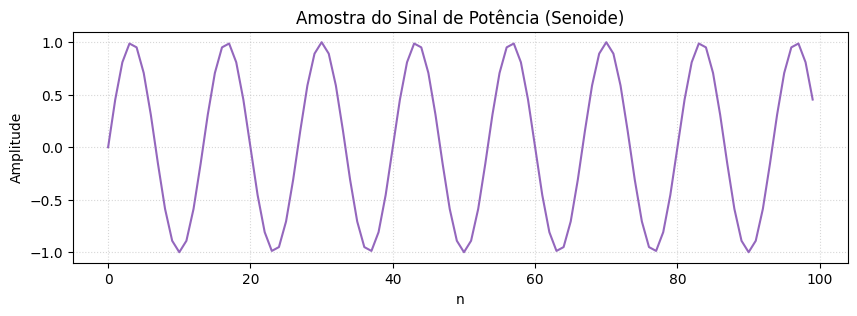

In [21]:
# 1. Cálculo da Energia Total (Sinal de Energia)
# Utilizamos o produto escalar do vetor por si mesmo para obter a soma dos quadrados
energia_total_x = np.dot(pulso_base, pulso_base)

# 2. Caracterização de um Sinal de Potência (Oscilação Infinita)
# Geramos um horizonte temporal amplo para aproximar o cálculo da potência
total_amostras = 2000
eixo_p = np.arange(total_amostras)
frequencia_angular = 0.15 * np.pi
sequencia_oscilante = np.sin(frequencia_angular * eixo_p)

# 3. Cálculo da Potência Média
# Calculamos a média aritmética dos quadrados das amplitudes
potencia_estimada = np.mean(np.square(np.abs(sequencia_oscilante)))

# 4. Exibição dos resultados formatados
print("-" * 45)
print(f"ANÁLISE ENERGÉTICA DE SEQUÊNCIAS")
print("-" * 45)
print(f"Energia do Pulso (Duração Finita): {energia_total_x:.2f} u.a.")
print(f"Potência Média (Sinal Periódico):  {potencia_estimada:.4f} u.a.")
print("-" * 45)

# Visualização rápida do sinal de potência (apenas as primeiras amostras)
plt.figure(figsize=(10, 3))
plt.plot(eixo_p[:100], sequencia_oscilante[:100], color='C4', lw=1.5)
plt.title("Amostra do Sinal de Potência (Senoide)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=':')
plt.show()

### 2.3 Síntese Técnica: Implementação em Hardware e Fluxo Energético

As transformações matemáticas aplicadas aos sinais discretos possuem uma tradução direta para a arquitetura de sistemas embarcados e dispositivos lógicos programáveis (FPGAs).

* **Deslocamento Temporal ($x[n-k]$):** Fisicamente, esta operação exige a presença de memória. Em hardware (RTL), o atraso de amostras é realizado através de cadeias de registradores sincronizados pelo mesmo *clock*.
* **Inversão Temporal ($x[-n]$):** É uma operação restrita ao processamento *offline*. Como exige acesso a amostras futuras, ela viola a causalidade, não podendo ser executada em tempo real em fluxos contínuos de dados de sensores.
* **Escalonamento:** É implementado por multiplicadores digitais ou, de forma mais eficiente, por deslocadores de bits (*bit-shifts*) quando o ganho é uma potência de dois.

A análise de energia e potência, discutida no **Problema Norteador**, é o que define o dimensionamento da aritmética de ponto fixo. Sinais de energia (leituras pontuais) e sinais de potência (ruídos de barramento) exigem estratégias diferentes de proteção contra *overflow* (transbordamento numérico) durante o processamento.

---

### 2.4 Decomposição de Sinais em Componentes de Simetria (Par e Ímpar)

Qualquer sequência discreta $x[n]$ pode ser decomposta na soma de duas funções fundamentais baseadas em sua simetria em relação à origem:

1.  **Componente Par ($x_p[n]$):** Exibe simetria especular ($x_p[n] = x_p[-n]$). É obtida pela média aritmética entre o sinal e sua versão invertida: $x_p[n] = \frac{x[n] + x[-n]}{2}$.
2.  **Componente Ímpar ($x_i[n]$):** Exibe antissimetria ($x_i[n] = -x_i[-n]$), sendo obrigatoriamente nula na origem. É calculada pela diferença: $x_i[n] = \frac{x[n] - x[-n]}{2}$.

O experimento abaixo utiliza uma rampa causal (sinal assimétrico) para demonstrar a extração exata dessas componentes.

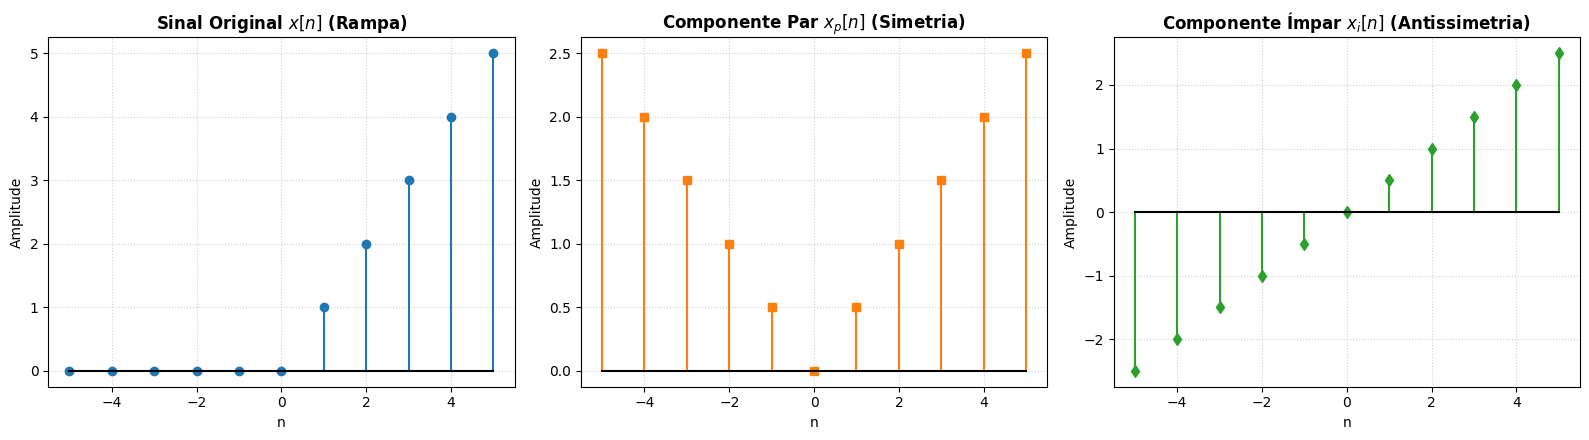

In [22]:
# 1. Criação do domínio simétrico para permitir a inversão
indices_n = np.arange(-5, 6)

# 2. Definição do sinal original: Rampa Unitária Causal
# x[n] = n para n >= 0, e 0 caso contrário
sinal_rampa = (indices_n * (indices_n >= 0)).astype(float)

# 3. Processamento de Inversão e Decomposição
# Inversão temporal utilizando indexação reversa do NumPy
sinal_invertido = sinal_rampa[::-1]

# Cálculo das partes simétricas
parte_par = 0.5 * (sinal_rampa + sinal_invertido)
parte_impar = 0.5 * (sinal_rampa - sinal_invertido)

# 4. Visualização dos Resultados (Layout Horizontal)
fig_simetria, eixos_s = plt.subplots(nrows=1, ncols=3, figsize=(16, 4.5))

# --- Gráfico: Sinal Original ---
eixos_s[0].stem(indices_n, sinal_rampa, linefmt='C0-', markerfmt='C0o', basefmt='k-')
eixos_s[0].set_title("Sinal Original $x[n]$ (Rampa)", fontsize=12, fontweight='bold')
eixos_s[0].grid(True, linestyle=':', alpha=0.6)

# --- Gráfico: Componente Par ---
eixos_s[1].stem(indices_n, parte_par, linefmt='C1-', markerfmt='C1s', basefmt='k-')
eixos_s[1].set_title("Componente Par $x_p[n]$ (Simetria)", fontsize=12, fontweight='bold')
eixos_s[1].grid(True, linestyle=':', alpha=0.6)

# --- Gráfico: Componente Ímpar ---
eixos_s[2].stem(indices_n, parte_impar, linefmt='C2-', markerfmt='C2d', basefmt='k-')
eixos_s[2].set_title("Componente Ímpar $x_i[n]$ (Antissimetria)", fontsize=12, fontweight='bold')
eixos_s[2].grid(True, linestyle=':', alpha=0.6)

# Configurações de eixos para todos os subplots
for ax in eixos_s:
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")

fig_simetria.tight_layout()
plt.show()

### 2.5 Escalonamento no Eixo Temporal: O Processo de Decimação

Diferente do ajuste de amplitude, o escalonamento da variável independente ($n$) modifica a velocidade com que a sequência é percorrida, alterando sua taxa de amostragem efetiva.

A operação $y[n] = x[Mn]$, onde $M$ é um inteiro maior que 1, define a **compressão temporal** ou **decimação**. No universo discreto, este processo implica na manutenção apenas das amostras cujos índices originais são múltiplos de $M$, resultando no descarte definitivo das demais informações. Fisicamente, isso equivale a reduzir a resolução temporal do sinal original.

A simulação a seguir ilustra o impacto da decimação por um fator $M=2$ em uma onda senoidal, evidenciando como a estrutura do sinal se torna mais "espaçada" após a subamostragem.

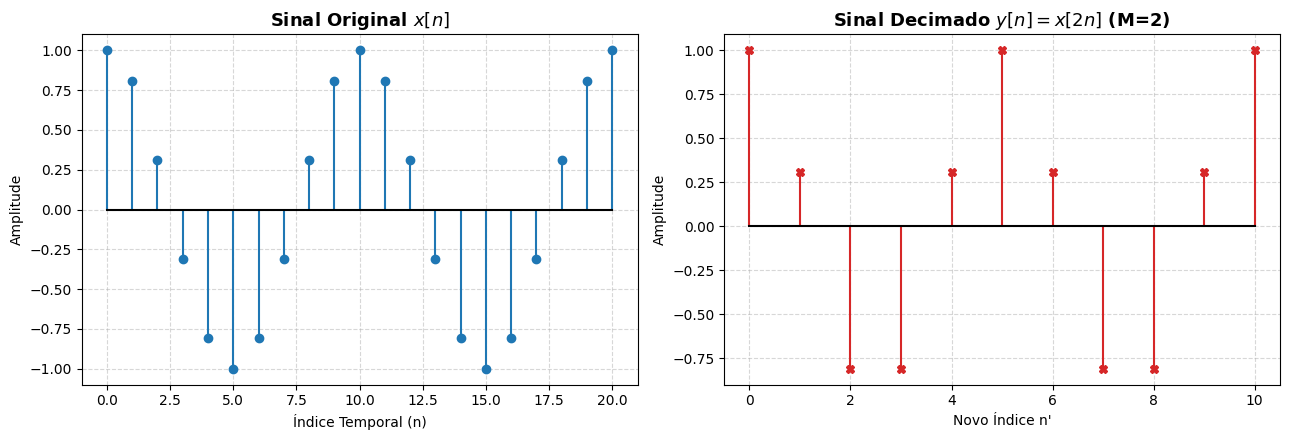

In [23]:
# 1. Geração da sequência senoidal de referência
amostras_t = np.arange(0, 21)
frequencia_base = 0.2 * np.pi
onda_original = np.cos(frequencia_base * amostras_t)

# 2. Implementação da Decimação (Subamostragem)
fator_m = 2
# Selecionamos os índices múltiplos de fator_m (0, 2, 4...)
indices_selecionados = np.arange(0, len(amostras_t), fator_m)
onda_decimada = np.take(onda_original, indices_selecionados)

# 3. Representação Visual Comparativa
fig_tempo, eixos_t = plt.subplots(nrows=1, ncols=2, figsize=(13, 4.5))

# --- Sinal em Alta Resolução (Original) ---
eixos_t[0].stem(amostras_t, onda_original, linefmt='C0-', markerfmt='C0o', basefmt='k-')
eixos_t[0].set_title(r"Sinal Original $x[n]$", fontsize=13, fontweight='bold')
eixos_t[0].set_xlabel("Índice Temporal (n)")
eixos_t[0].set_ylabel("Amplitude")
eixos_t[0].grid(True, linestyle='--', alpha=0.5)

# --- Sinal Subamostrado (Decimado) ---
# Usamos cor vermelha ('C3') e marcadores 'X' para enfatizar a perda de amostras
eixos_t[1].stem(np.arange(len(onda_decimada)), onda_decimada, linefmt='C3-', markerfmt='C3X', basefmt='k-')
eixos_t[1].set_title(f"Sinal Decimado $y[n] = x[{fator_m}n]$ (M={fator_m})", fontsize=13, fontweight='bold')
eixos_t[1].set_xlabel("Novo Índice n'")
eixos_t[1].set_ylabel("Amplitude")
eixos_t[1].grid(True, linestyle='--', alpha=0.5)

# Ajuste fino e exibição
fig_tempo.tight_layout()
plt.show()

### 2.6 Síntese Técnica: Engenharia de Sistemas Multitaxa e Hardware

Embora a decomposição em componentes de simetria (par e ímpar) possua um papel fundamental na simplificação de cálculos de transformadas e séries de Fourier, é o **escalonamento temporal** que exerce um impacto crítico na engenharia de hardware de alto desempenho.

* **Processamento Multitaxa (Multirate):** A operação de decimação ($y[n] = x[Mn]$) é a base dos sistemas que operam com múltiplas taxas de amostragem. Em arquiteturas reais, como as que utilizam conversores **Sigma-Delta**, a decimação é empregada para reduzir o volume de dados logo após uma sobreamostragem inicial.
* **Otimização de Recursos:** Fisicamente, ao reduzirmos a taxa de dados através da decimação, permitimos que a lógica sequencial subsequente opere em frequências de *clock* menores. Isso resulta em uma redução direta do **consumo de potência dinâmica** e facilita o fechamento de *timing* (restrições temporais) durante a síntese de circuitos integrados.
* **Controle de Perda de Informação:** A perda de amostras, inerente à matemática da decimação, é mitigada em hardware através do uso de filtros digitais passas-baixas (**filtros anti-aliasing**), garantindo que o sinal resultante não sofra com o fenômeno do dobramento espectral.

Essa compreensão fecha a análise das propriedades estruturais de sinais, preparando o terreno para o estudo de como os sistemas processam essas sequências através da convolução.

# Seção 3: Modelagem e Atributos de Sistemas Discretos

A caracterização de sistemas em tempo discreto fundamenta-se na identificação das regras que regem a relação dinâmica entre a excitação de entrada $x[n]$ e a resposta de saída $y[n]$. A classificação matemática de um sistema é o que define tanto a sua viabilidade de implementação em hardware quanto as metodologias analíticas necessárias para prever seu comportamento.

Neste estágio, exploramos a implementação computacional de sistemas com e sem memória, além de testar a propriedade da linearidade. As demais características (estabilidade, causalidade e invariância) serão detalhadas na sequência deste estudo.

### 3.1 Classificação quanto à Memória: Sistemas Estáticos vs. Dinâmicos

Um sistema é denominado **sem memória** (ou estático) quando sua saída no índice $n$ é determinada única e exclusivamente pelo valor da entrada no exato mesmo instante $n$. Matematicamente, a relação segue a forma $y[n] = f(x[n])$.

Em contrapartida, um sistema possui **memória** (ou é dinâmico) se a sua resposta depender de valores anteriores ($x[n-k]$) ou posteriores ($x[n+k]$) da entrada. Fisicamente, a implementação de memória exige elementos de armazenamento de estado, como registradores ou buffers.

O script a seguir modela um processador estático de ganho ($y_1[n] = 2.5 \cdot x[n]$) e um integrador discreto simples ($y_2[n] = x[n] + x[n-1]$), simulando suas respostas a um estímulo impulsivo.

<>:25: SyntaxWarning: invalid escape sequence '\c'
<>:25: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_17643/2236989097.py:25: SyntaxWarning: invalid escape sequence '\c'
  eixos_sys[1].set_title("Sistema Sem Memória (Estático)\n$y[n] = 2.5 \cdot x[n]$")


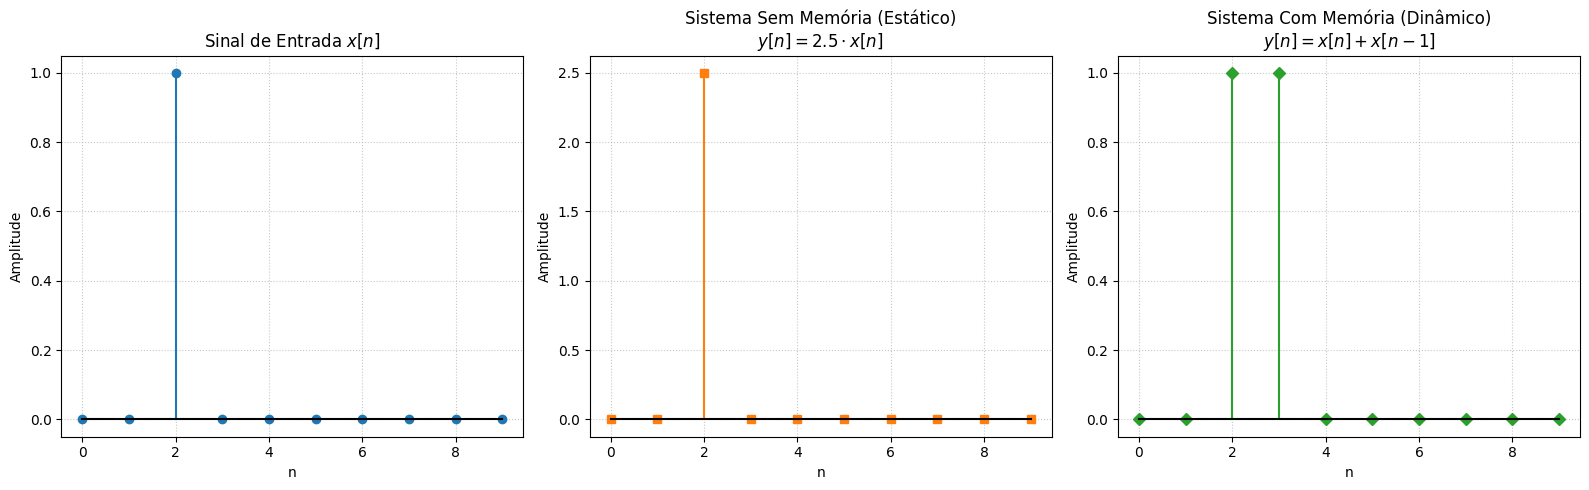

In [24]:
# 1. Base temporal e sinal de excitação
amostras_s = np.arange(0, 10)
# Pulso unitário localizado em n=2
entrada_impulso = (amostras_s == 2).astype(float)

# 2. Implementação do Sistema 1: Sem Memória (Ganho Linear)
# A saída depende apenas do valor atual de x[n]
saida_estatica = 2.5 * entrada_impulso

# 3. Implementação do Sistema 2: Com Memória (Atraso e Acúmulo)
# Criamos o sinal atrasado x[n-1] garantindo causalidade (preenchendo com zero no início)
atraso_x = np.concatenate(([0], entrada_impulso[:-1]))
saida_dinamica = entrada_impulso + atraso_x

# 4. Visualização dos Comportamentos do Sistema
fig_sys, eixos_sys = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

# --- Gráfico de Entrada ---
eixos_sys[0].stem(amostras_s, entrada_impulso, linefmt='C0-', markerfmt='C0o', basefmt='k-')
eixos_sys[0].set_title("Sinal de Entrada $x[n]$")
eixos_sys[0].grid(True, linestyle=':', alpha=0.7)

# --- Gráfico Sistema Estático ---
eixos_sys[1].stem(amostras_s, saida_estatica, linefmt='C1-', markerfmt='C1s', basefmt='k-')
eixos_sys[1].set_title("Sistema Sem Memória (Estático)\n$y[n] = 2.5 \cdot x[n]$")
eixos_sys[1].grid(True, linestyle=':', alpha=0.7)

# --- Gráfico Sistema Dinâmico ---
eixos_sys[2].stem(amostras_s, saida_dinamica, linefmt='C2-', markerfmt='C2D', basefmt='k-')
eixos_sys[2].set_title("Sistema Com Memória (Dinâmico)\n$y[n] = x[n] + x[n-1]$")
eixos_sys[2].grid(True, linestyle=':', alpha=0.7)

# Ajustes de legenda e eixos
for ax in eixos_sys:
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")

fig_sys.tight_layout()
plt.show()

### 3.2 O Princípio da Superposição: Verificação de Linearidade

A linearidade é, talvez, a propriedade mais restritiva e importante na análise de sistemas. Para que um sistema seja classificado como **Linear**, ele deve satisfazer obrigatoriamente o Princípio da Superposição, que se divide em dois pilares fundamentais:

1.  **Aditividade:** A resposta do sistema a uma soma de sinais ($x_1[n] + x_2[n]$) deve ser exatamente igual à soma das respostas individuais ($y_1[n] + y_2[n]$).
2.  **Homogeneidade (Escalonamento):** Alterar a amplitude da entrada por um fator $a$ deve provocar uma alteração proporcional na saída por esse mesmo fator $a$.

Um sistema que falha em qualquer um desses critérios é classificado como **Não Linear**. Matematicamente, testamos se:
$$T\{a \cdot x_1[n] + b \cdot x_2[n]\} = a \cdot T\{x_1[n]\} + b \cdot T\{x_2[n]\}$$

O experimento computacional abaixo confronta um operador de ganho linear ($y = 4x$) com um operador quadrático ($y = x^2$) para validar essa propriedade através do cálculo do erro de superposição.

VERIFICAÇÃO DO PRINCÍPIO DA SUPERPOSIÇÃO
Sistema y[n] = 4x[n]  | Resíduo: 0.00e+00 | Linear: True
Sistema y[n] = x[n]^2 | Resíduo: 3.94 | Linear: False


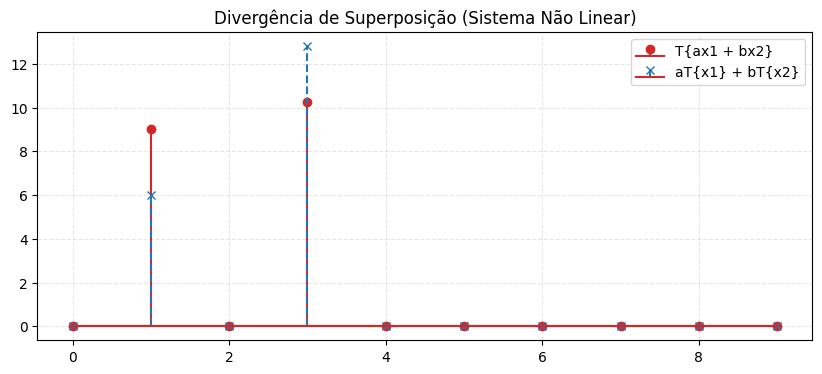

In [25]:
# Nota: Assume-se que 'amostras_s' (vetor n de 0 a 9) já existe na memória.

# 1. Definição de dois sinais de teste distintos e constantes de escala
sinal_a = (amostras_s == 1).astype(float) * 2.0  # Pulso em n=1 com amp=2
sinal_b = (amostras_s == 3).astype(float) * 4.0  # Pulso em n=3 com amp=4
alfa, beta = 1.5, 0.8

# 2. Definição dos Operadores (Sistemas) usando expressões Lambda
# Sistema A: Ganho simples (Linear) | Sistema B: Potenciação (Não Linear)
operador_lin = lambda x: 4 * x
operador_n_lin = lambda x: x**2

# 3. Teste de Superposição para o Sistema Linear
saida_combinada_l = operador_lin(alfa * sinal_a + beta * sinal_b)
saida_individual_l = alfa * operador_lin(sinal_a) + beta * operador_lin(sinal_b)
delta_linear = np.linalg.norm(saida_combinada_l - saida_individual_l)

# 4. Teste de Superposição para o Sistema Não Linear
saida_combinada_nl = operador_n_lin(alfa * sinal_a + beta * sinal_b)
saida_individual_nl = alfa * operador_n_lin(sinal_a) + beta * operador_n_lin(sinal_b)
delta_n_linear = np.linalg.norm(saida_combinada_nl - saida_individual_nl)

# 5. Apresentação Técnica dos Resultados
print("="*50)
print("VERIFICAÇÃO DO PRINCÍPIO DA SUPERPOSIÇÃO")
print("="*50)
print(f"Sistema y[n] = 4x[n]  | Resíduo: {delta_linear:.2e} | Linear: {delta_linear < 1e-10}")
print(f"Sistema y[n] = x[n]^2 | Resíduo: {delta_n_linear:.2f} | Linear: {delta_n_linear < 1e-10}")
print("="*50)

# Visualização da falha de superposição no sistema não linear
plt.figure(figsize=(10, 4))
plt.stem(amostras_s, saida_combinada_nl, linefmt='C3-', markerfmt='C3o', label='T{ax1 + bx2}')
plt.stem(amostras_s, saida_individual_nl, linefmt='C0--', markerfmt='C0x', label='aT{x1} + bT{x2}')
plt.title("Divergência de Superposição (Sistema Não Linear)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.3 Atributo de Causalidade: Sistemas de Tempo Real vs. Não Real

A causalidade define se um sistema é fisicamente realizável em tempo real. Classificamos um sistema como **Causal** quando a sua resposta no instante $n$ depende exclusivamente de valores atuais ($x[n]$) e/ou de eventos passados ($x[n-k]$). Essencialmente, um sistema causal não consegue reagir a um estímulo antes que este ocorra.

Por outro lado, um sistema é **Não Causal** se a sua saída depender de amostras futuras da entrada ($x[n+k]$). Embora matematicamente possíveis em algoritmos de processamento de sinais já armazenados em memória (processamento *offline*), estes sistemas não podem ser implementados em fluxos de dados em direto, pois exigem a "antecipação" de eventos.

O experimento abaixo confronta um sistema de atraso e acumulação (causal) com um sistema de avanço temporal (não causal), expondo como o sinal de saída se posiciona no tempo em relação ao pulso de entrada.

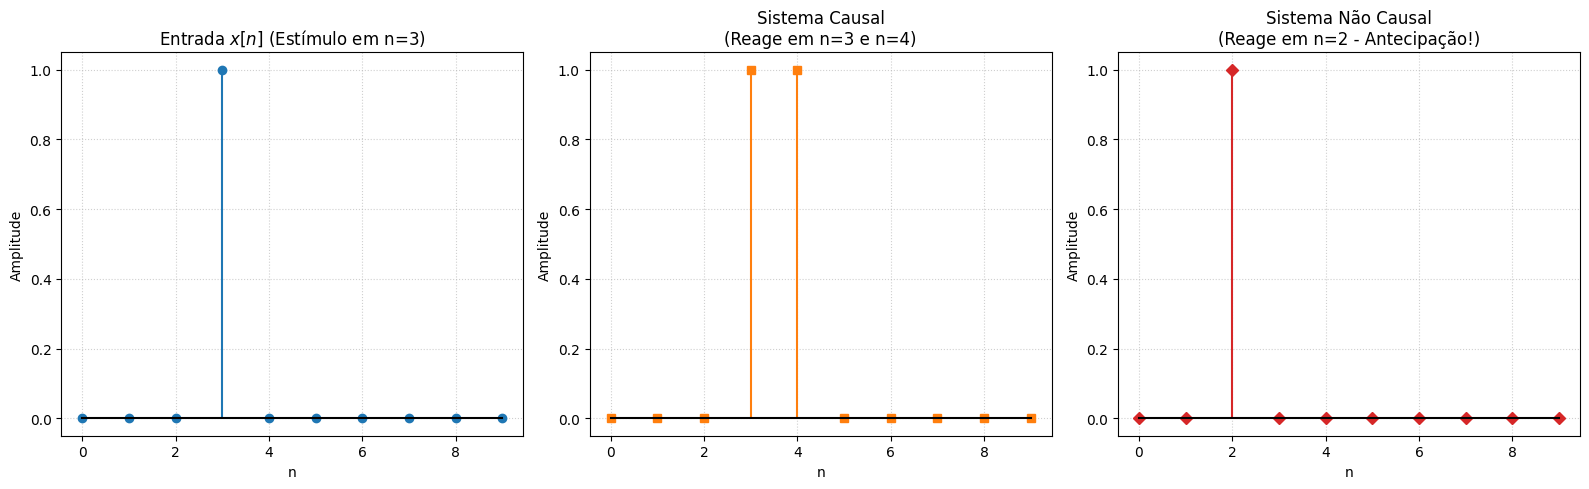

In [26]:
# 1. Definição do horizonte temporal e sinal de teste (excitação em n=3)
n_idx = np.arange(0, 10)
x_impulso = (n_idx == 3).astype(float)

# 2. Implementação do Sistema Causal: y[n] = x[n] + x[n-1]
# Usamos np.pad para criar o atraso de forma elegante
x_atrasado = np.pad(x_impulso[:-1], (1, 0), mode='constant')
saida_causal = x_impulso + x_atrasado

# 3. Implementação do Sistema Não Causal: y[n] = x[n+1]
# A saída no instante n depende do valor que a entrada terá no instante n+1
saida_antecipada = np.pad(x_impulso[1:], (0, 1), mode='constant')

# 4. Representação Visual dos Comportamentos
fig_cau, eixos_c = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

# --- Sinal de Entrada ---
eixos_c[0].stem(n_idx, x_impulso, linefmt='C0-', markerfmt='C0o', basefmt='k-')
eixos_c[0].set_title("Entrada $x[n]$ (Estímulo em n=3)")
eixos_c[0].grid(True, linestyle=':', alpha=0.6)

# --- Resposta Causal ---
eixos_c[1].stem(n_idx, saida_causal, linefmt='C1-', markerfmt='C1s', basefmt='k-')
eixos_c[1].set_title("Sistema Causal\n(Reage em n=3 e n=4)")
eixos_c[1].grid(True, linestyle=':', alpha=0.6)

# --- Resposta Não Causal ---
eixos_c[2].stem(n_idx, saida_antecipada, linefmt='C3-', markerfmt='C3D', basefmt='k-')
eixos_c[2].set_title("Sistema Não Causal\n(Reage em n=2 - Antecipação!)")
eixos_c[2].grid(True, linestyle=':', alpha=0.6)

# Rotulagem comum
for ax in eixos_c:
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")

fig_cau.tight_layout()
plt.show()

### 3.4 Invariância Temporal: Consistência de Processamento

Um sistema é classificado como **Invariante no Tempo** (ou estacionário) quando as suas propriedades de transformação não oscilam ao longo do eixo cronológico. Em termos práticos, se uma entrada $x[n]$ produz uma saída $y[n]$, então uma versão atrasada dessa entrada, $x[n-k]$, deve gerar exatamente a mesma saída atrasada, $y[n-k]$, sem qualquer deformação no formato do sinal.

Quando os parâmetros ou ganhos do sistema dependem explicitamente da variável de tempo $n$, o sistema é denominado **Variante no Tempo**. Nestes casos, o instante em que o sinal é injetado altera drasticamente a natureza da resposta.

O experimento a seguir valida esta propriedade comparando um sistema de ganho fixo (invariante) com um sistema de modulação temporal (variante), aplicando um deslocamento de duas amostras para observar se a morfologia do sinal de saída é preservada.

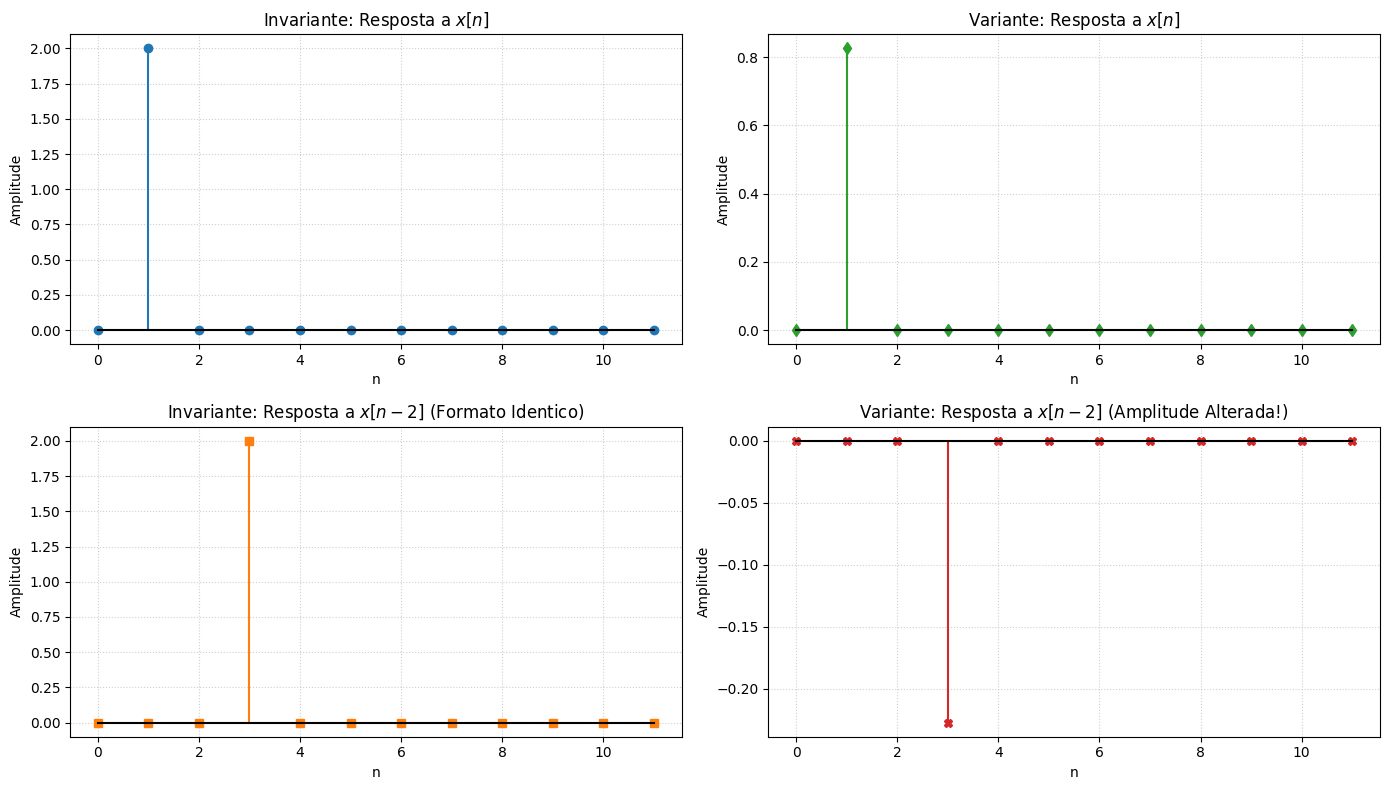

In [27]:
# 1. Definição do domínio temporal e sinais de teste (pulso original e atrasado)
eixo_n = np.arange(0, 12)
k_atraso = 2
x_ref = (eixo_n == 1).astype(float)        # Pulso em n=1
x_atraso = (eixo_n == (1 + k_atraso)).astype(float) # Pulso em n=3

# 2. Modelagem dos Sistemas
# Sistema A: Invariante (Ganho estático de 2.0)
sist_fixo = lambda x: 2.0 * x

# Sistema B: Variante (Ganho modulado pela posição n)
# Aqui usamos uma função cosseno para variar o ganho dependendo de n
sist_mutavel = lambda x, n: np.cos(0.6 * n) * x

# 3. Execução dos Testes
y_fixo_orig = sist_fixo(x_ref)
y_fixo_atr = sist_fixo(x_atraso)

y_mut_orig = sist_mutavel(x_ref, eixo_n)
y_mut_atr = sist_mutavel(x_atraso, eixo_n)

# 4. Visualização Comparativa (Layout 2x2)
fig_inv, area_inv = plt.subplots(2, 2, figsize=(14, 8))

# --- Coluna 1: Sistema Invariante ---
area_inv[0, 0].stem(eixo_n, y_fixo_orig, linefmt='C0-', markerfmt='C0o', basefmt='k-')
area_inv[0, 0].set_title("Invariante: Resposta a $x[n]$")

area_inv[1, 0].stem(eixo_n, y_fixo_atr, linefmt='C1-', markerfmt='C1s', basefmt='k-')
area_inv[1, 0].set_title(f"Invariante: Resposta a $x[n-{k_atraso}]$ (Formato Identico)")

# --- Coluna 2: Sistema Variante ---
area_inv[0, 1].stem(eixo_n, y_mut_orig, linefmt='C2-', markerfmt='C2d', basefmt='k-')
area_inv[0, 1].set_title("Variante: Resposta a $x[n]$")

area_inv[1, 1].stem(eixo_n, y_mut_atr, linefmt='C3-', markerfmt='C3X', basefmt='k-')
area_inv[1, 1].set_title(f"Variante: Resposta a $x[n-{k_atraso}]$ (Amplitude Alterada!)")

# Ajustes estéticos
for ax in area_inv.flat:
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")
    ax.grid(True, linestyle=':', alpha=0.6)

fig_inv.tight_layout()
plt.show()

### 3.5 Estabilidade BIBO: Confiabilidade e Limitação de Saída

A estabilidade **BIBO** (*Bounded-Input Bounded-Output*) é o critério que garante que um sistema não "explodirá" ou acumulará energia indefinidamente. Matematicamente, um sistema é estável se qualquer entrada de amplitude limitada ($|x[n]| \le M_x < \infty$) produzir, obrigatoriamente, uma saída também limitada ($|y[n]| \le M_y < \infty$).

Sistemas que não satisfazem esta condição são classificados como **Instáveis**. Um exemplo clássico de instabilidade é o acumulador puro: ao receber um sinal constante (como o degrau unitário), a sua saída cresce linearmente até o infinito (ou até o limite de memória do hardware), perdendo o controle da amplitude.

A simulação abaixo contrasta a resposta de um filtro de média móvel atenuado (estável) com a de um integrador discreto (instável) sob a excitação de um sinal de degrau unitário.

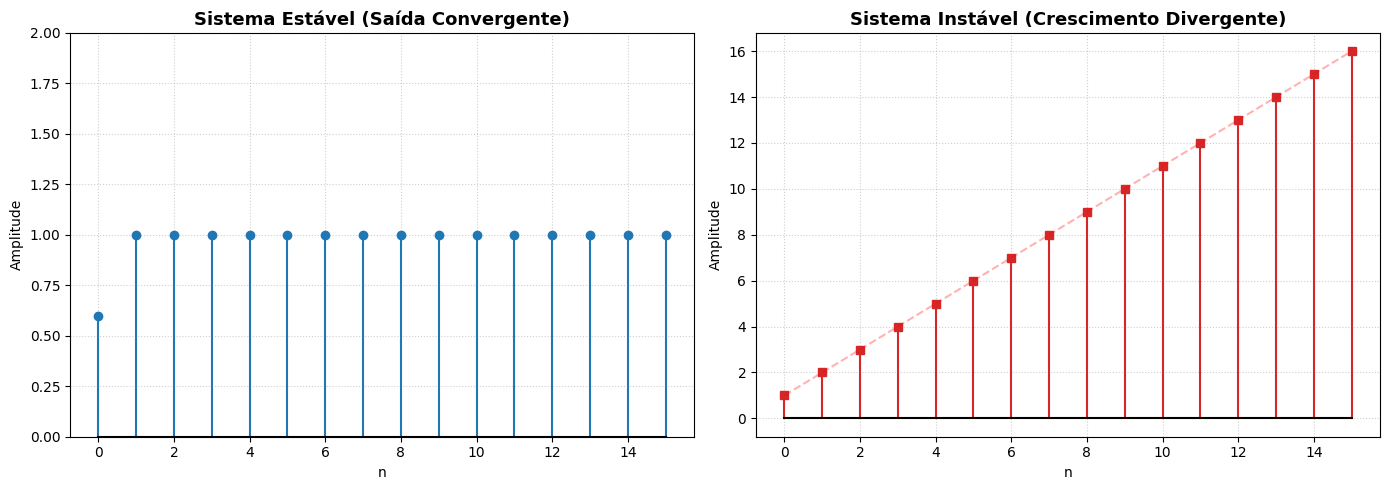

In [30]:
# 1. Definição do intervalo de observação e entrada (Degrau Unitário)
amostras_b = np.arange(0, 16)
entrada_u = np.ones(len(amostras_b))

# 2. Sistema A: Filtro Estável (Média Móvel Suavizada)
# y[n] = 0.6 * x[n] + 0.4 * x[n-1]
u_atrasado = np.pad(entrada_u[:-1], (1, 0), constant_values=0)
saida_estavel = 0.6 * entrada_u + 0.4 * u_atrasado

# 3. Sistema B: Acumulador (Instável)
# y[n] = soma de todos os valores de x de 0 até n
saida_instavel = np.cumsum(entrada_u)

# 4. Visualização dos Resultados
fig_bibo, eixos_b = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# --- Gráfico do Sistema Estável ---
eixos_b[0].stem(amostras_b, saida_estavel, linefmt='C0-', markerfmt='C0o', basefmt='k-')
eixos_b[0].set_title("Sistema Estável (Saída Convergente)", fontsize=13, fontweight='bold')
eixos_b[0].set_ylim(0, 2) # Eixo limitado para mostrar estabilidade
eixos_b[0].grid(True, linestyle=':', alpha=0.6)

# --- Gráfico do Sistema Instável ---
# Usamos cor vermelha e uma linha de tendência tracejada para mostrar o crescimento
eixos_b[1].stem(amostras_b, saida_instavel, linefmt='C3-', markerfmt='C3s', basefmt='k-')
eixos_b[1].plot(amostras_b, saida_instavel, 'r--', alpha=0.3)
eixos_b[1].set_title("Sistema Instável (Crescimento Divergente)", fontsize=13, fontweight='bold')
eixos_b[1].grid(True, linestyle=':', alpha=0.6)

# Configurações de eixos
for ax in eixos_b:
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")

fig_bibo.tight_layout()
plt.show()

### 3.6 Invertibilidade: Recuperação de Dados e Sistemas Inversos

Um sistema é classificado como **Invertível** se existe uma correspondência biunívoca (um para um) entre as sequências de entrada e saída. Em termos práticos, isso significa que entradas distintas devem obrigatoriamente gerar saídas distintas, não permitindo ambiguidades.

A importância desta propriedade reside na possibilidade de projetar um **Sistema Inverso** ($W$), que, quando conectado em cascata com o sistema original ($H$), anula as transformações impostas por este, recuperando integralmente o sinal original:
$$w[n] * (h[n] * x[n]) = x[n]$$

Se um sistema "perde" informação (como um elevador ao quadrado para sinais positivos e negativos ou um sistema que multiplica tudo por zero), ele é considerado **Não Invertível**.

O script abaixo simula um processo de ganho e sua respectiva atenuação inversa, validando a integridade da reconstrução do sinal através do cálculo do resíduo de recuperação.

<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_17643/1779433874.py:22: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(eixo_indices, sinal_reconstruido, 'rX', markersize=10, label='Recuperado $\hat{x}[n]$')


Relatório Técnico: Sistema Invertível verificado. Resíduo: 0.00e+00


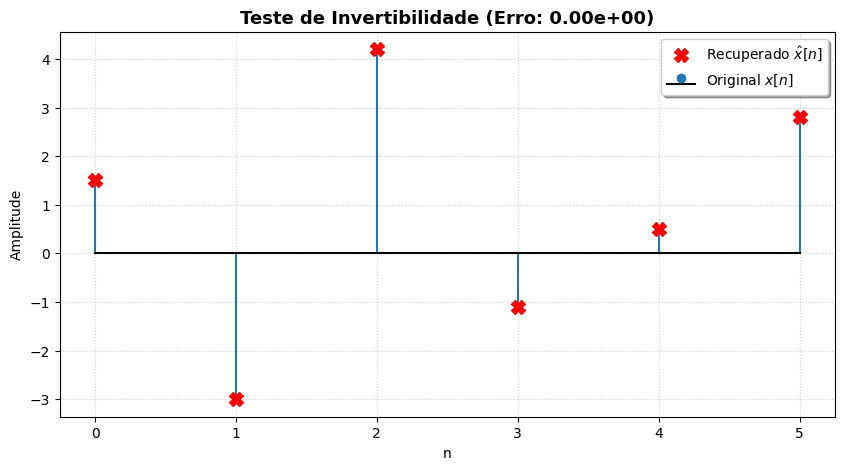

In [31]:
# 1. Definição de um sinal de dados arbitrário
sinal_original = np.array([1.5, -3.0, 4.2, -1.1, 0.5, 2.8])
eixo_indices = np.arange(len(sinal_original))

# 2. Sistema Invertível (H): Ganho de Amplitude
# y[n] = 4 * x[n]
fator_ganho = 4.0
sinal_processado = fator_ganho * sinal_original

# 3. Sistema Inverso (W): Recuperação
# x_hat[n] = 0.25 * y[n]
sinal_reconstruido = (1.0 / fator_ganho) * sinal_processado

# 4. Cálculo da Fidelidade (Erro de Reconstrução)
residuo_inversao = np.linalg.norm(sinal_original - sinal_reconstruido)

# 5. Visualização da Recuperação
plt.figure(figsize=(10, 5))

# Plotagem do original (azul) e reconstruído (pontos vermelhos)
plt.stem(eixo_indices, sinal_original, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Original $x[n]$')
plt.plot(eixo_indices, sinal_reconstruido, 'rX', markersize=10, label='Recuperado $\hat{x}[n]$')

plt.title(f"Teste de Invertibilidade (Erro: {residuo_inversao:.2e})", fontsize=13, fontweight='bold')
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend(frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

print(f"Relatório Técnico: Sistema Invertível verificado. Resíduo: {residuo_inversao:.2e}")
plt.show()

### 3.7 Síntese Técnica: Da Abstração Matemática às Restrições de Hardware

A análise das propriedades estruturais é o que define se um algoritmo de processamento digital é viável para implementação em silício. As equações matemáticas traduzem-se diretamente em restrições físicas:

* **Causalidade e RTL:** A causalidade é um requisito absoluto para sistemas de tempo real. Em projetos de hardware (como em *SystemVerilog* ou *VHDL*), utilizamos bancos de registradores estritamente para gerenciar amostras passadas, alinhando a lógica sequencial à impossibilidade física de acessar dados futuros.
* **Invariância e Área de Silício:** Sistemas invariantes permitem que a lógica combinacional sintetizada (somadores e multiplicadores) utilize coeficientes fixos, otimizando drasticamente a área ocupada no chip.
* **Estabilidade e ALUs:** A estabilidade BIBO previne falhas críticas em unidades aritméticas. Em aritmética de ponto fixo, sistemas instáveis geram *overflow* (transbordamento), corrompendo os dados. Ferramentas de verificação de *design* (EDA) asseguram que a arquitetura preserve esta estabilidade sob qualquer condição.

---

### 3.8 Arquiteturas de Filtragem: Sistemas FIR (Não Recursivos) vs. IIR (Recursivos)

Além das classificações clássicas, os sistemas são divididos pela presença ou ausência de realimentação (*feedback*):

1.  **Sistemas Não Recursivos (FIR - *Finite Impulse Response*):** A saída $y[n]$ depende apenas de valores atuais e passados da entrada $x[n]$. Caracterizam-se por terem uma resposta ao impulso de duração finita e serem inerentemente estáveis.
2.  **Sistemas Recursivos (IIR - *Infinite Impulse Response*):** A saída depende da entrada e também de valores anteriores da própria saída ($y[n-k]$). Isso cria um laço de realimentação que faz com que a resposta ao impulso decaia infinitamente no tempo, exigindo maior cuidado com a estabilidade.

A simulação abaixo contrasta um filtro de média móvel (FIR) com um sistema de primeira ordem com realimentação (IIR), evidenciando a diferença na duração de suas respostas.

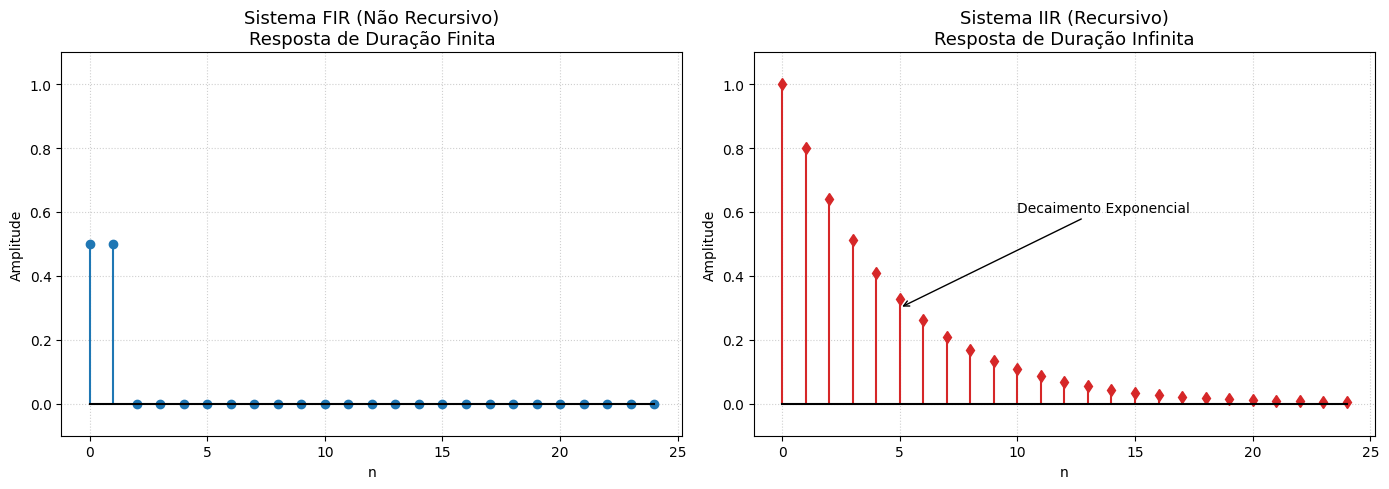

In [32]:
# 1. Geração do Estímulo (Impulso Unitário na origem)
janela_n = np.arange(0, 25)
delta_entrada = (janela_n == 0).astype(float)

# 2. Implementação do Sistema FIR (Não Recursivo)
# y[n] = 0.5*x[n] + 0.5*x[n-1]
atraso_entrada = np.pad(delta_entrada[:-1], (1, 0), constant_values=0)
saida_fir = 0.5 * delta_entrada + 0.5 * atraso_entrada

# 3. Implementação do Sistema IIR (Recursivo)
# y[n] = 0.8 * y[n-1] + x[n]
# Simulamos a recursão de forma eficiente
saida_iir = np.zeros(len(janela_n))
for n in range(len(janela_n)):
    # y[n] = x[n] + 0.8 * y[n-1] (considerando y[-1] = 0)
    saida_iir[n] = delta_entrada[n] + (0.8 * saida_iir[n-1] if n > 0 else 0)

# 4. Visualização e Comparação Técnica
fig_filtros, eixos_f = plt.subplots(1, 2, figsize=(14, 5))

# --- Resposta FIR ---
eixos_f[0].stem(janela_n, saida_fir, linefmt='C0-', markerfmt='C0o', basefmt='k-')
eixos_f[0].set_title("Sistema FIR (Não Recursivo)\nResposta de Duração Finita", fontsize=13)
eixos_f[0].set_ylim(-0.1, 1.1)
eixos_f[0].grid(True, linestyle=':', alpha=0.6)

# --- Resposta IIR ---
# Usamos cor vermelha e marcadores em diamante para o decaimento infinito
eixos_f[1].stem(janela_n, saida_iir, linefmt='C3-', markerfmt='C3d', basefmt='k-')
eixos_f[1].set_title("Sistema IIR (Recursivo)\nResposta de Duração Infinita", fontsize=13)
eixos_f[1].set_ylim(-0.1, 1.1)
eixos_f[1].grid(True, linestyle=':', alpha=0.6)

# Anotação de decaimento
eixos_f[1].annotate('Decaimento Exponencial', xy=(5, 0.3), xytext=(10, 0.6),
                    arrowprops=dict(facecolor='black', arrowstyle='->'))

for ax in eixos_f:
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")

fig_filtros.tight_layout()
plt.show()

# Conclusão da Parte 1

Com a realização destes experimentos e análises, concluímos a primeira etapa do Estudo Dirigido. Através da modelagem computacional, validamos as propriedades fundamentais que regem o comportamento de sinais e sistemas discretos.

As simulações demonstraram que a representação matemática de um sensor real exige a compreensão de fenômenos como a decimação, a estabilidade e a causalidade, garantindo que o processamento digital seja não apenas teoricamente correto, mas fisicamente realizável em sistemas embarcados e hardware de alto desempenho.